# Euclidean VAE

In [1]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [2]:
%pwd
%load_ext autoreload
%autoreload 2

### Imports

In [3]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace


### Set up and initialize data loader

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [5]:
loader_config = {
    "dataset_name": "s2_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "n_times": 10000,
    "radius": 2.0,
    "major_radius": 2.0,
    "minor_radius": 1.0,
    # "radius_inner": 1,
    # "radius_outer": 3,
    "n_wiggles": 0,
    "geodesic_distortion_amp": 0,
    "embedding_dim": 3,
    "noise_var": 0.00001,
    "geodesic_distortion_func": "wiggles",
    "filled": False,
    "filled1": False,
    "filled2": False,
    "translation": None,
    }

model_config = {
    'model_type': 'EuclideanVAE',
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 3,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [32, 32, 32],
    'decoder_widths': [32, 32]}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'verbose': False,
    'num_epochs': 2,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'dim_topo_loss': 1,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss
}

curvature_config = {
    "quadric_dim": 2,
    "n_plot_points": 1000,   
    "n_grid_points": 800,  # to compute curvature
    "k": 160  # k-nearest neighbor
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)


### Dataloader

In [6]:
dataloader = dataloader.load_synthetic_ds(config)
train_loader, test_loader = dataloader

print(test_loader)

# from torch.utils.data import DataLoader
# from torch_topological.datasets import Spheres
# import torch
# 
# n_spheres = 10
# 
# # Train set
# data_set = Spheres(n_spheres=n_spheres)
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# train_loader = DataLoader(
#     data_set,
#     batch_size=32,
#     shuffle=True,
#     drop_last=True
# )
# 
# # Test set
# data_set = Spheres(
#     train=False,
#     n_samples=2000,
#     n_spheres=n_spheres,
# )
# data_set = [(x[0].double(), x[1]) for x in data_set]
# 
# test_loader = DataLoader(
#     data_set,
#     shuffle=False,
#     batch_size=len(data_set)
# )
# 
# dataloader = train_loader, test_loader

angle_grid tensor([[0.0100, 0.0000],
        [0.0100, 0.0635],
        [0.0100, 0.1269],
        ...,
        [3.1416, 6.1563],
        [3.1416, 6.2197],
        [3.1416, 6.2832]])


### Model

In [7]:
model = model.EuclideanVAE(config)

### Optimizer

In [8]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [9]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Epoch 1/2, Train Loss: 3.0045, Test Loss: 1.4025
--------------------------------------------------
Epoch 2/2, Train Loss: 0.9899, Test Loss: 0.7929
--------------------------------------------------


### Plot history

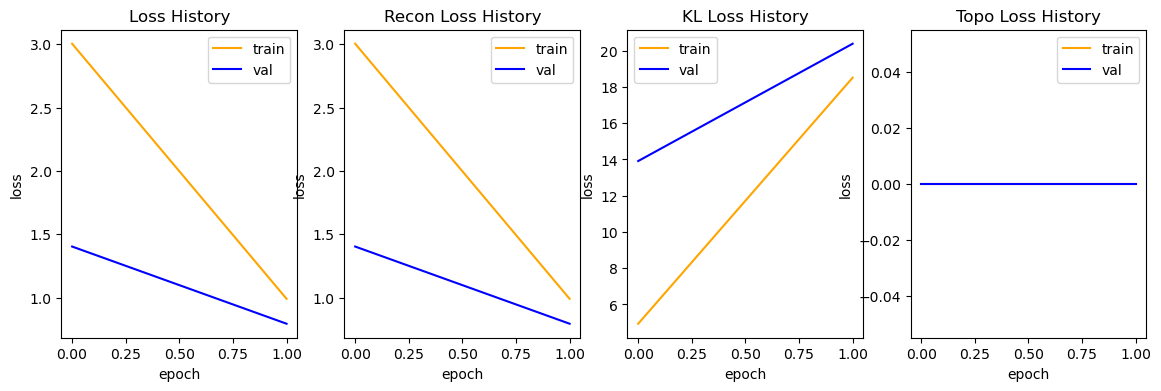

In [10]:
utils.show_training_history(history)

### Visualizing the latent space

Forwarding data through model...


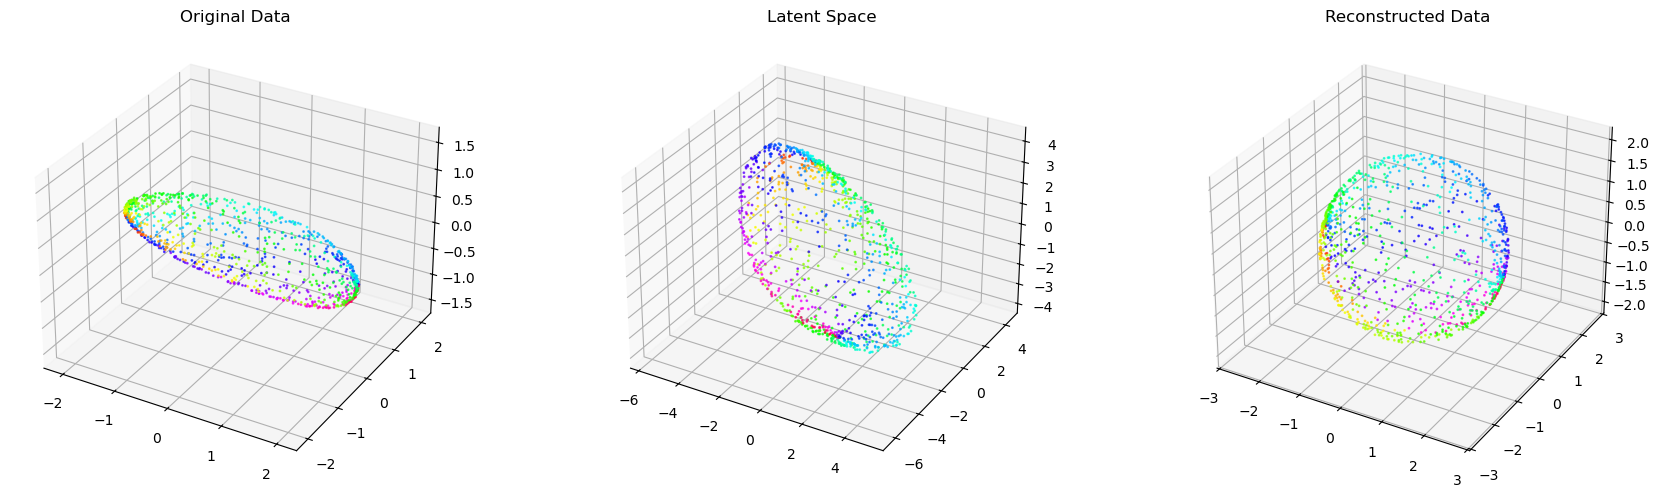

In [11]:
utils.plot_data_latents_recon(config, model, test_loader)

### Plot reconstructed manifold

### Compute curvature error

Forwarding data through model...
Computing learned curvature...
Starting actual computation...
Curvature computation finished.
Computing true curvature on latent vectors...
Starting actual computation...
Curvature computation finished.
curvature_true tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.000

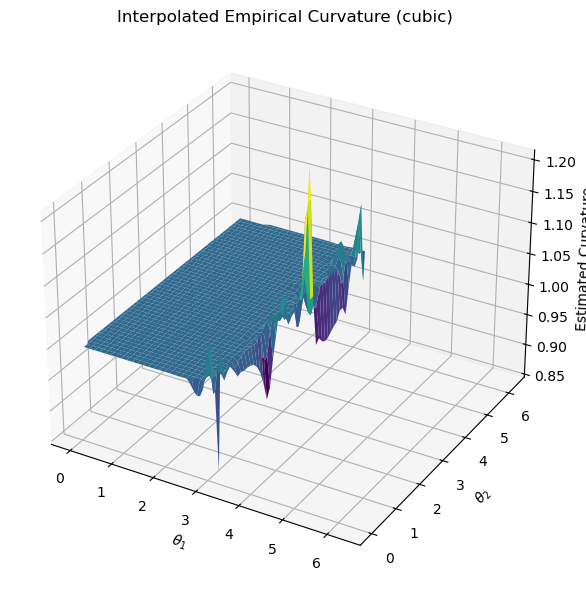

In [12]:
utils.plot_empiric_curvature(config=config, model=model, data_loader=test_loader)

In [13]:
_,_,_,labels = utils.get_vectors(config, model, test_loader)

Forwarding data through model...


In [14]:
#immersion = utils.get_true_immersion(config)
rot = torch.eye(3)
immersion = utils.get_s2_synthetic_immersion(10, 0, 3, rot)
utils._compute_curvature(labels, immersion, 2, 3)

Starting actual computation...
Curvature computation finished.


(tensor([[-9.4454e-04, -1.7629e-03, -1.9999e-01],
         [ 1.9999e-03,  6.3461e-05, -1.9999e-01],
         [ 1.3095e-03,  1.5118e-03, -1.9999e-01],
         [ 7.7270e-04,  1.8447e-03, -1.9999e-01],
         [-1.8069e-03,  8.5969e-04, -1.9999e-01],
         [-1.9648e-03,  3.7849e-04, -1.9999e-01],
         [-1.9624e-03, -8.0893e-03, -1.9983e-01],
         [ 7.9867e-03,  2.3451e-03, -1.9983e-01],
         [-1.4640e-02,  0.0000e+00, -1.9946e-01],
         [-1.1215e-02, -9.4103e-03, -1.9946e-01],
         [-9.2312e-03,  1.1363e-02, -1.9946e-01],
         [-3.6363e-03, -2.0623e-02, -1.9890e-01],
         [ 1.6461e-02,  1.2945e-02, -1.9890e-01],
         [ 4.2888e-03,  2.0497e-02, -1.9890e-01],
         [-3.6364e-03,  2.0623e-02, -1.9890e-01],
         [-9.8898e-03,  1.8458e-02, -1.9890e-01],
         [-1.9701e-02, -1.8785e-02, -1.9814e-01],
         [-6.4176e-03,  2.6454e-02, -1.9814e-01],
         [ 4.7638e-03,  3.3133e-02, -1.9718e-01],
         [-3.4686e-02,  1.9299e-02, -1.9602e-01],
